# Supplementary Figure 7

Quantitative panels A and C show low-DEG finding categories and their neuronal contexts.

In [1]:
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

%config InlineBackend.figure_format = "retina"

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src/manuscript_figures/figS7").exists():
    ROOT = ROOT.parent
if not (ROOT / "src/manuscript_figures/figS7").exists():
    raise FileNotFoundError("Run this notebook from the distributed_agent repository.")

S7 = ROOT / "src/manuscript_figures/figS7"
ANALYSIS = S7 / "analysis"
plt.style.use(ROOT / "src/manuscript_figures/style.mplstyle")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})

In [2]:
findings = pd.read_csv(ANALYSIS / "finding_types.csv")
target_burden = pd.read_csv(ANALYSIS / "target_deg_burden.csv")
category1 = pd.read_csv(ANALYSIS / "category1_expanded.csv")
deg_matrix_full = pd.read_csv(ANALYSIS / "deg_coverage_matrix.csv")

assert list(findings.columns) == ["target_gene", "finding_type"]
assert len(findings) == 10_898
assert target_burden["target_gene"].nunique() == 1_946
assert len(category1) == 27 and category1["family"].nunique() == 13
assert deg_matrix_full.shape == (23, 1_947)  # cell-class label + 1,946 targets

print(f"Finding ledger: {len(findings):,} findings across {findings.target_gene.nunique():,} non-control targets")
print(f"Category-1 set: {len(category1)} targets across {category1.family.nunique()} mechanistic families")
print(f"DEG matrix: {deg_matrix_full.shape[0]} neuronal classes × {deg_matrix_full.shape[1] - 1:,} targets")

Finding ledger: 10,898 findings across 1,946 non-control targets
Category-1 set: 27 targets across 13 mechanistic families
DEG matrix: 23 neuronal classes × 1,946 targets


## A — Finding categories along the DEG-signal axis

In [3]:
LOW_DEG_MAX = 10
burden = target_burden.set_index("target_gene")["deg_burden"]
is_low = findings["target_gene"].map(burden).le(LOW_DEG_MAX)

low_counts = Counter(findings.loc[is_low, "finding_type"])
higher_counts = Counter(findings.loc[~is_low, "finding_type"])
n_low, n_higher = sum(low_counts.values()), sum(higher_counts.values())
finding_types = sorted(
    set(low_counts) | set(higher_counts),
    key=lambda kind: (low_counts[kind] / n_low) / max(higher_counts[kind] / n_higher, 1e-9),
)
enrichment_values = np.array([
    np.log2((low_counts[kind] / n_low) / max(higher_counts[kind] / n_higher, 1e-9))
    for kind in finding_types
])
enrichment_table = pd.DataFrame({
    "finding_type": finding_types,
    "low_DEG_findings": [low_counts[kind] for kind in finding_types],
    "higher_DEG_findings": [higher_counts[kind] for kind in finding_types],
    "log2_share_ratio": enrichment_values,
})

FAMILY = {
    "negative_result": "null",
    "cross_perturbation_contrast": "prior-driven",
    "pathway_uncoupling": "prior-driven",
    "therapeutic_direction_warning": "prior-driven",
    "disease_mechanism_refinement": "prior-driven",
    "literature_direction_mismatch": "prior-driven",
    "biomarker_candidate": "measurement-grounded",
    "convergent_module": "measurement-grounded",
    "cell_type_selectivity": "measurement-grounded",
    "homeostatic_compensation": "measurement-grounded",
    "buffered_response": "measurement-grounded",
    "other": "measurement-grounded",
}
BINS = [(0, 0, "0"), (1, 10, "1–10"), (11, 100, "11–100"),
        (101, 1_000, "101–1k"), (1_001, 10**9, ">1k")]
FAM_ORDER = ["measurement-grounded", "prior-driven", "null"]

bin_families = {label: Counter() for _, _, label in BINS}
bin_sizes = Counter()
for row in findings.itertuples(index=False):
    value = int(burden[row.target_gene])
    label = next(label for lo, hi, label in BINS if lo <= value <= hi)
    bin_families[label][FAMILY[row.finding_type]] += 1
    bin_sizes[label] += 1

composition_rows = []
for _, _, label in BINS:
    row = {"DEG_burden": label, "n_findings": bin_sizes[label]}
    row.update({family: 100 * bin_families[label][family] / bin_sizes[label] for family in FAM_ORDER})
    composition_rows.append(row)
composition_table = pd.DataFrame(composition_rows)

assert int((target_burden.deg_burden <= 10).sum()) == 1_677
assert [bin_sizes[label] for _, _, label in BINS] == [4_618, 4_618, 1_006, 445, 211]
assert enrichment_table.set_index("finding_type").loc["negative_result", "log2_share_ratio"] > 1.18

display(enrichment_table.round({"log2_share_ratio": 2}))
display(composition_table.round(1))

,finding_type,low_DEG_findings,higher_DEG_findings,log2_share_ratio
0,convergent_module,166,207,-2.79
1,homeostatic_compensation,96,49,-1.50
2,literature_direction_mismatch,38,14,-1.03
3,biomarker_candidate,452,151,-0.89
4,other,29,9,-0.79
5,cell_type_selectivity,1157,262,-0.33
6,buffered_response,1157,199,0.07
7,cross_perturbation_contrast,1337,213,0.18
8,therapeutic_direction_warning,1027,157,0.24
9,disease_mechanism_refinement,833,120,0.32


,DEG_burden,n_findings,measurement-grounded,prior-driven,null
0,0,4618,26.5,50.6,23.0
1,1–10,4618,39.7,45.2,15.1
2,11–100,1006,52.4,38.6,9.0
3,101–1k,445,53.7,39.3,7.0
4,>1k,211,52.6,39.3,8.1


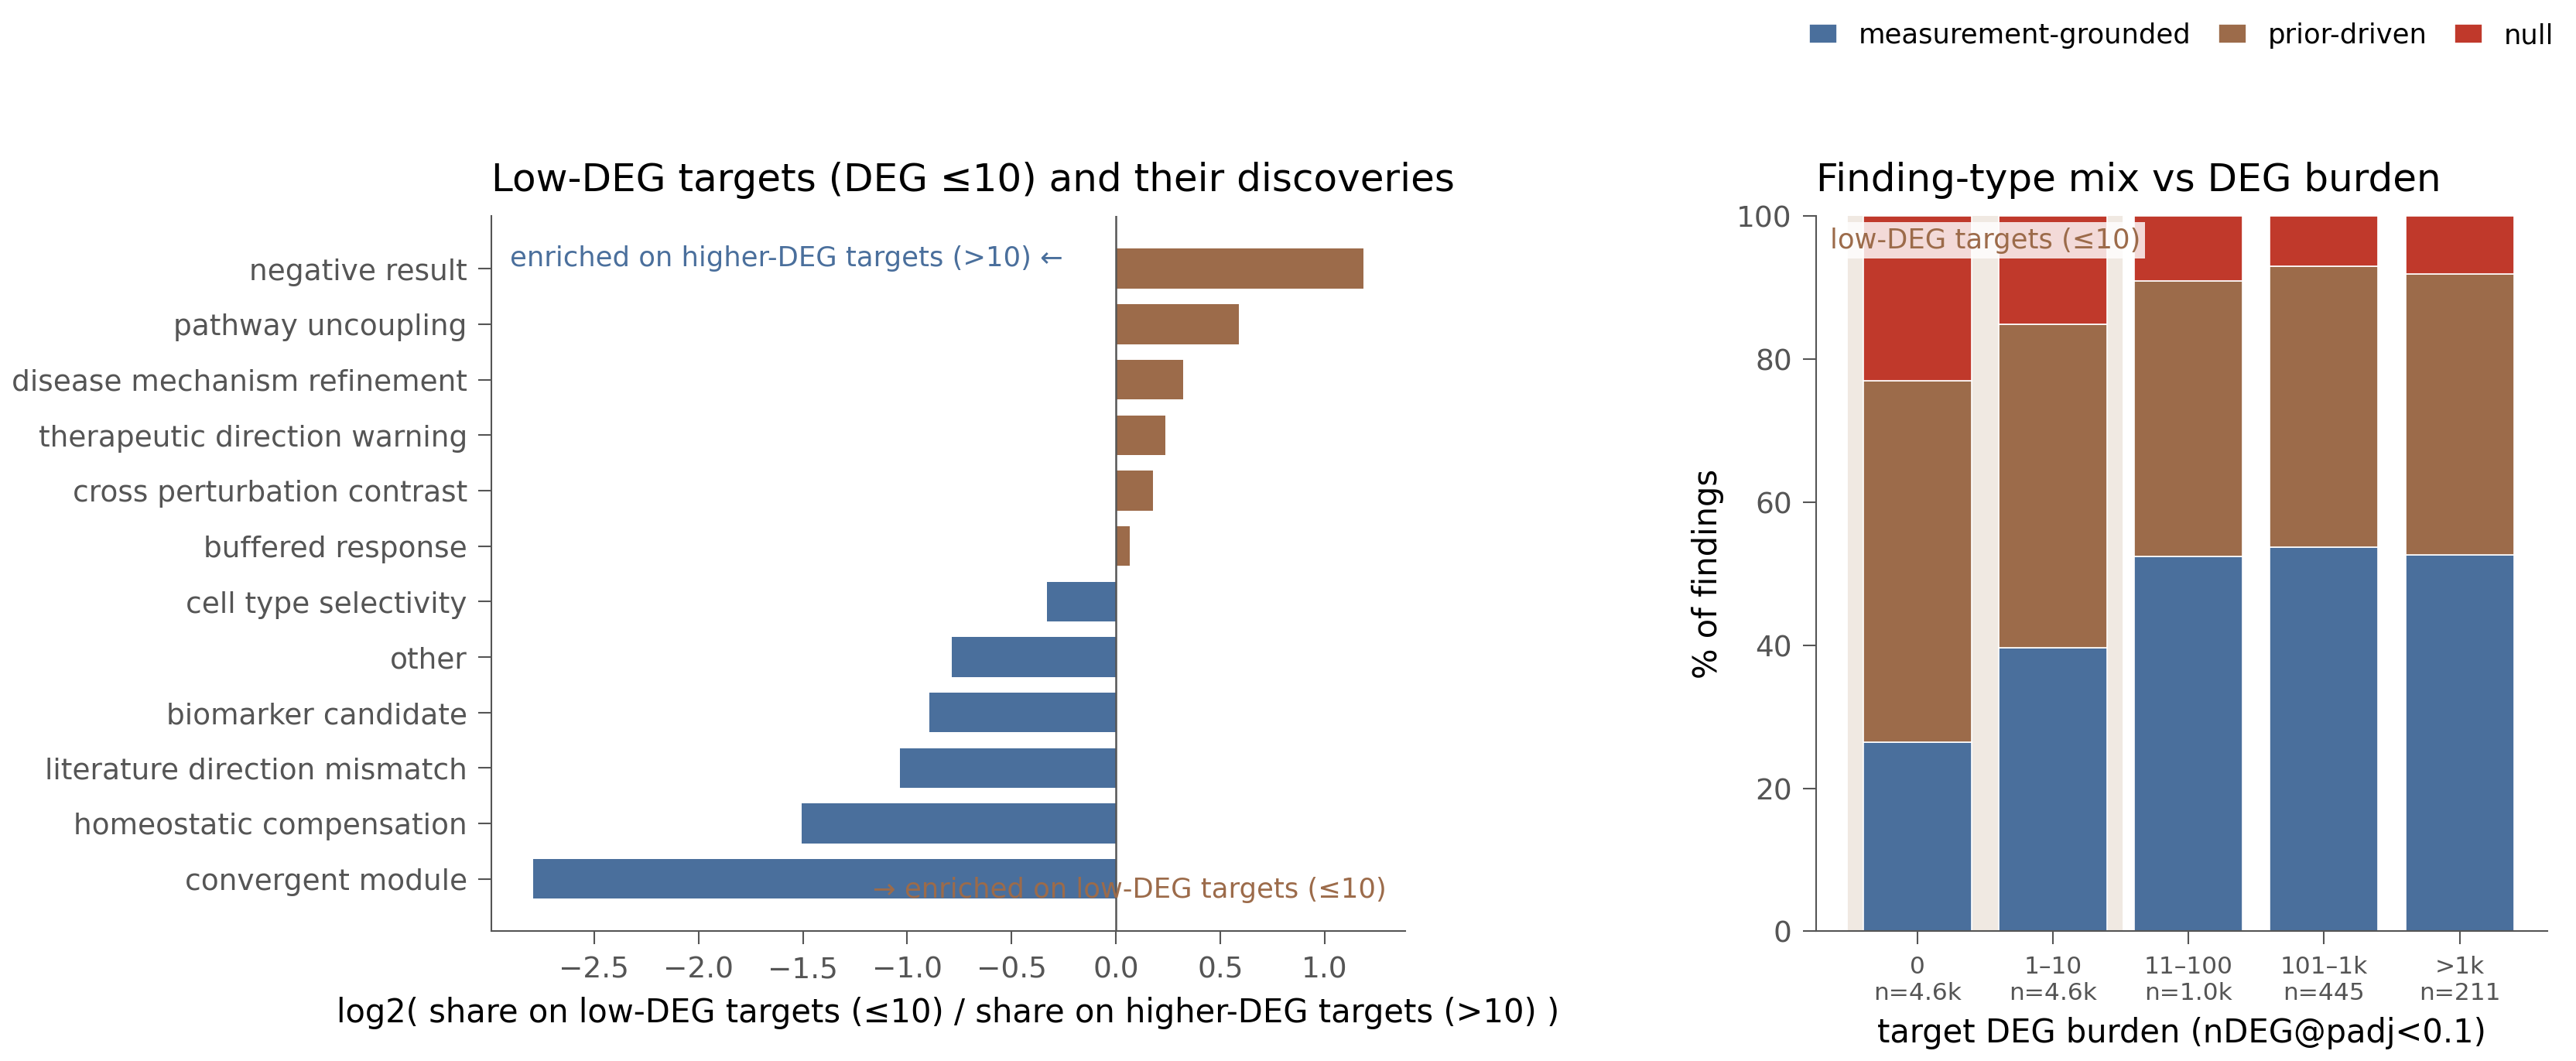

In [4]:
NULL_C, PRIOR_C, MEAS_C = "#c0392b", "#9c6b4a", "#4a6f9c"
FAM_COLOR = {"null": NULL_C, "prior-driven": PRIOR_C, "measurement-grounded": MEAS_C}

fig = plt.figure(figsize=(11.5, 5.5))
grid = GridSpec(1, 2, figure=fig, width_ratios=[1.25, 1.0], wspace=0.50,
                left=0.20, right=0.97, top=0.74, bottom=0.18)
ax_enrich = fig.add_subplot(grid[0, 0])
ax_mix = fig.add_subplot(grid[0, 1])

y = np.arange(len(finding_types))
colors = [PRIOR_C if value > 0 else MEAS_C for value in enrichment_values]
ax_enrich.barh(y, enrichment_values, color=colors, height=0.72, linewidth=0)
ax_enrich.axvline(0, color="#555555", lw=0.6)
ax_enrich.set_yticks(y)
ax_enrich.set_yticklabels([kind.replace("_", " ") for kind in finding_types], fontsize=9)
ax_enrich.set_xlabel(
    "log2( share on low-DEG targets (≤10) / share on higher-DEG targets (>10) )", fontsize=10
)
ax_enrich.set_title("Low-DEG targets (DEG ≤10) and their discoveries", fontsize=12, loc="left", pad=8)
ax_enrich.tick_params(axis="x", labelsize=9)
ax_enrich.text(0.98, 0.04, "→ enriched on low-DEG targets (≤10)", transform=ax_enrich.transAxes,
               fontsize=8.5, color=PRIOR_C, ha="right", va="bottom")
ax_enrich.text(0.02, 0.96, "enriched on higher-DEG targets (>10) ←", transform=ax_enrich.transAxes,
               fontsize=8.5, color=MEAS_C, ha="left", va="top")

labels = [label for _, _, label in BINS]
x = np.arange(len(labels))
ax_mix.axvspan(-0.5, 1.5, color="#f0e9e2", zorder=0)
ax_mix.text(0.5, 98.5, "low-DEG targets (≤10)", fontsize=8.5, color=PRIOR_C,
            ha="center", va="top", bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 1.5})
bottom = np.zeros(len(labels))
for family in FAM_ORDER:
    values = np.array([100 * bin_families[label][family] / bin_sizes[label] for label in labels])
    ax_mix.bar(x, values, bottom=bottom, width=0.8, color=FAM_COLOR[family], label=family,
               linewidth=0.4, edgecolor="white")
    bottom += values
ax_mix.set_xticks(x)
ax_mix.set_xticklabels([
    f"{label}\nn={bin_sizes[label] / 1000:.1f}k" if bin_sizes[label] >= 1000
    else f"{label}\nn={bin_sizes[label]:,}"
    for label in labels
], fontsize=7.5)
ax_mix.set_ylim(0, 100)
ax_mix.set_ylabel("% of findings", fontsize=10)
ax_mix.set_xlabel("target DEG burden (nDEG@padj<0.1)", fontsize=10)
ax_mix.set_title("Finding-type mix vs DEG burden", fontsize=12, loc="left", pad=8)
ax_mix.tick_params(axis="y", labelsize=9)
ax_mix.legend(fontsize=8.5, loc="lower center", bbox_to_anchor=(0.5, 1.20),
              ncol=3, frameon=False, handlelength=1.0, columnspacing=1.0)
plt.show()

## C — Literature-agreement findings in neuronal contexts

In [5]:
CANON_ORDER = [
    "001 L5-6 IT Glut", "005 L4-5 IT CTX Glut", "007 L2-3 IT CTX Glut",
    "008 L2-3 IT ENT PPP RSP Glut", "009 L2-3 IT PIR AON ENT Glut", "022 L5 ET CTX Glut",
    "027 NP-CT-L6b-OB Glut", "012 MEA LA CA1 DG Glut", "017 CA3 CA2-FC DG Glut",
    "046 CTX-CGE GABA", "052 Pvalb Gaba", "053 Sst Gaba", "054 CNU-MGE GABA",
    "059 CNU-LGE LSX GABA", "066 CNU-HYa HY GABA", "110 CNU-HYa HY MM Glut",
    "145 MH-LH TH Glut", "151 TH Prkcd Grin2c Glut", "155 MB Glut", "191 MB P MY GABA",
    "215 MB Dopa", "217 P MY Pineal Glut", "308 CB GABA",
]
ROW = {cell: index for index, cell in enumerate(CANON_ORDER)}
FAM_ORDER_C = [
    "ether-lipid→sterol", "chromatin derepression", "neurotrophin RAS-ERK→Vgf",
    "sterol/SREBP", "tubulin autoregulation", "activity-dependent IEG",
    "UPR/ER-chaperone", "integrated stress response", "TF target/complex",
    "chaperone/HSF1", "cytoskeletal/axon", "mito biogenesis", "IFN/MHC-I",
]
FAM_SHORT = {
    "ether-lipid→sterol": "ether-lipid\n→ sterol", "chromatin derepression": "chromatin\nderepression",
    "neurotrophin RAS-ERK→Vgf": "RAS-ERK\n→ Vgf", "sterol/SREBP": "sterol/\nSREBP",
    "tubulin autoregulation": "tubulin\nautoreg.", "activity-dependent IEG": "activity\nIEG",
    "UPR/ER-chaperone": "UPR", "integrated stress response": "ISR\n(ATF4)",
    "TF target/complex": "TF\ntarget", "chaperone/HSF1": "HSF1",
    "cytoskeletal/axon": "axon", "mito biogenesis": "mito-\nbiogen.", "IFN/MHC-I": "IFN/\nMHC-I",
}

matrix = deg_matrix_full.set_index("cell_class").reindex(CANON_ORDER)
display_target_count = 1_919
empty_tail = matrix.iloc[:, display_target_count:]
assert empty_tail.shape[1] == 27 and float(empty_tail.to_numpy().sum()) == 0.0
matrix = matrix.iloc[:, :display_target_count]
D = matrix.to_numpy(dtype=float)
columns = list(matrix.columns)
column_index = {target: index for index, target in enumerate(columns)}

category1 = category1.copy()
category1["cells"] = category1["cell_types"].fillna("").apply(
    lambda value: [cell for cell in value.split("|") if cell]
)
category1["family_rank"] = category1["family"].map({family: i for i, family in enumerate(FAM_ORDER_C)})
category1 = category1.sort_values(["family_rank", "deg_burden"]).reset_index(drop=True)
target_order = list(category1["target"])
assert set(target_order).issubset(column_index)
assert all(int(D[:, column_index[row.target]].sum()) == int(row.deg_burden) for row in category1.itertuples())

family_summary = (category1.groupby("family", sort=False)
                  .agg(n_targets=("target", "size"), targets=("target", lambda values: ", ".join(values)))
                  .reset_index())
print(f"Displayed matrix: {D.shape[0]} neuronal classes × {D.shape[1]:,} targets; max cell burden={int(D.max()):,}")
print(f"Selected set: {len(category1)} targets, {category1.family.nunique()} families, "
      f"{sum(map(len, category1.cells))} target × finding-class placements")
display(family_summary)

Displayed matrix: 23 neuronal classes × 1,919 targets; max cell burden=3,622
Selected set: 27 targets, 13 families, 71 target × finding-class placements


,family,n_targets,targets
0,ether-lipid→sterol,4,"Agps, Far1, Selenoi, Pcyt2"
1,chromatin derepression,4,"Phf21a, Zeb1, Setdb1, Rb1"
2,neurotrophin RAS-ERK→Vgf,3,"Shoc2, Braf, Ntrk2"
3,sterol/SREBP,2,"Marchf6, Srebf2"
4,tubulin autoregulation,2,"Tbce, Tbcd"
5,activity-dependent IEG,2,"Kcnb1, Slc12a5"
6,UPR/ER-chaperone,2,"Dpm1, Sec63"
7,integrated stress response,2,"Lonp1, Bdp1"
8,TF target/complex,2,"Nfat5, Thap1"
9,chaperone/HSF1,1,Hspa8


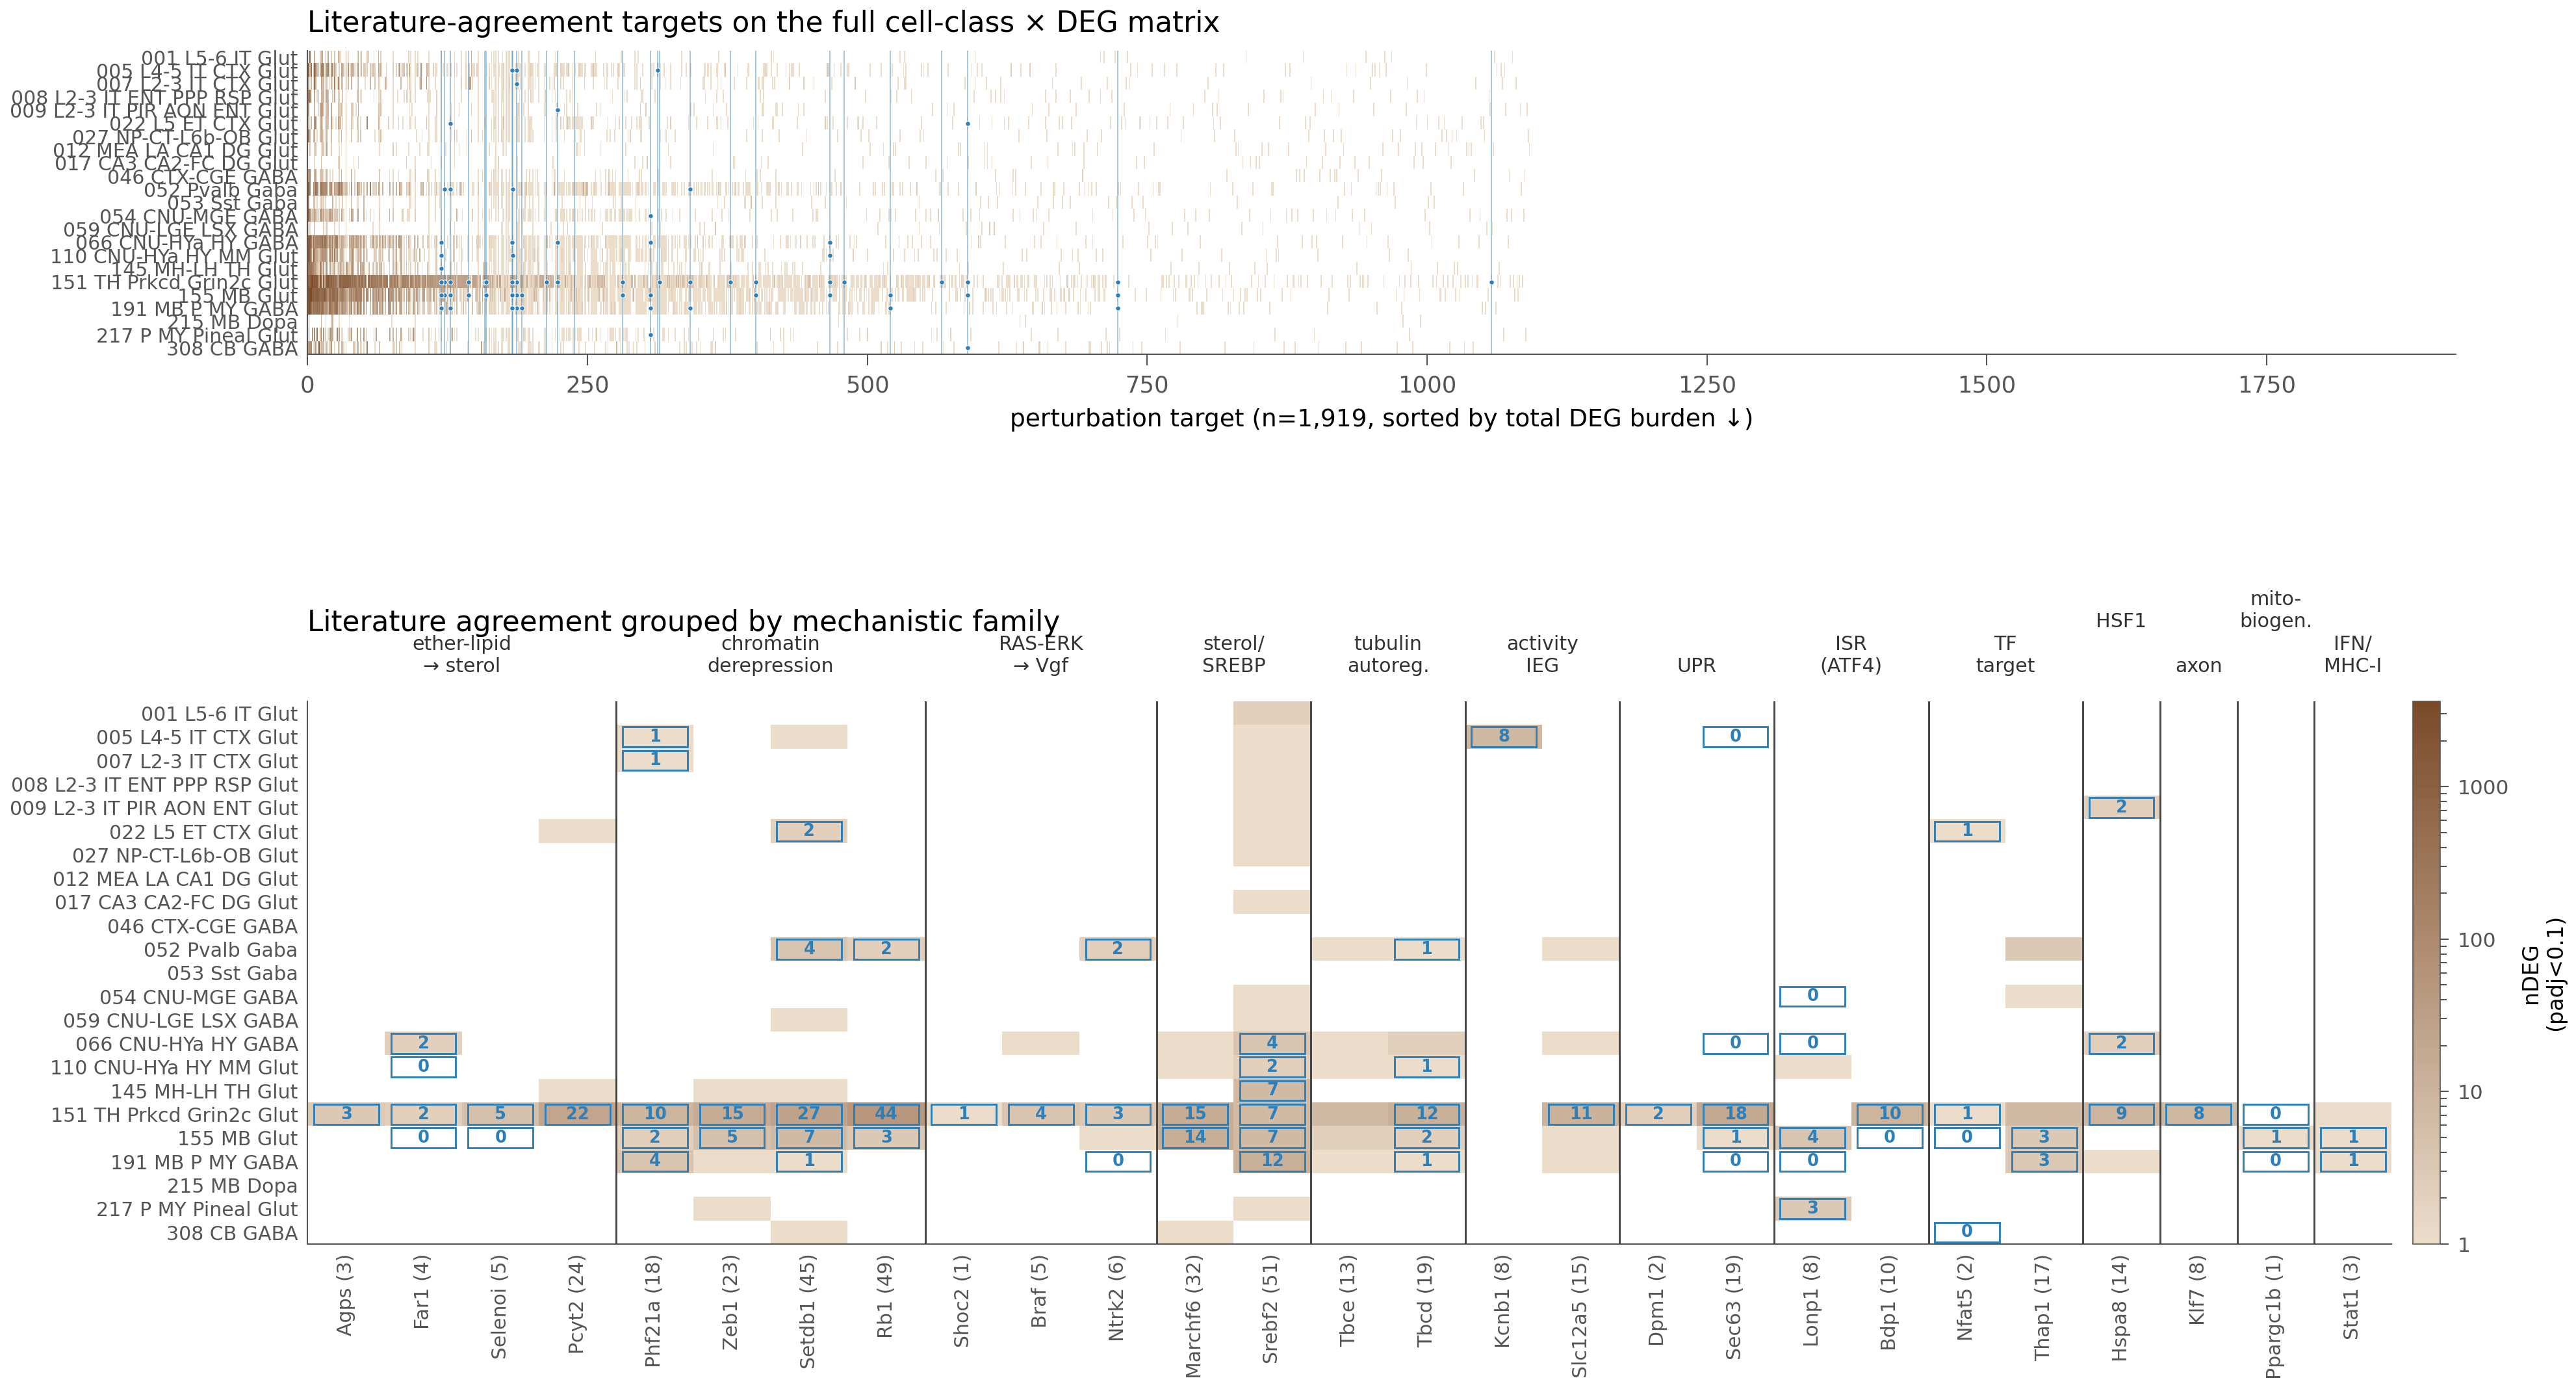

In [6]:
DEG_CMAP = LinearSegmentedColormap.from_list("DEGbrown", ["#ecddcb", "#7a4a28"])
DEG_CMAP.set_bad("white")
HIGHLIGHT = "#2c7fb8"
norm = LogNorm(vmin=1, vmax=float(D.max()))

fig = plt.figure(figsize=(14.5, 8.5))
grid = GridSpec(2, 1, figure=fig, height_ratios=[0.70, 1.25], hspace=0.82,
                left=0.16, right=0.92, top=0.94, bottom=0.22)
ax_full = fig.add_subplot(grid[0])
ax_focus = fig.add_subplot(grid[1])

ax_full.imshow(np.where(D >= 1, D, np.nan), aspect="auto", cmap=DEG_CMAP, norm=norm,
               interpolation="nearest", origin="upper",
               extent=[0, D.shape[1], len(CANON_ORDER), 0])
ax_full.set_facecolor("white")
ax_full.set_xlim(0, D.shape[1])
ax_full.set_yticks(np.arange(len(CANON_ORDER)) + 0.5)
ax_full.set_yticklabels(CANON_ORDER, fontsize=7.2)
ax_full.tick_params(axis="y", length=0)
ax_full.tick_params(axis="x", labelsize=8.5)
ax_full.set_xlabel(
    f"perturbation target (n={D.shape[1]:,}, sorted by total DEG burden ↓)", fontsize=9
)
for target in target_order:
    column = column_index[target]
    ax_full.axvline(column + 0.5, color=HIGHLIGHT, lw=0.4, alpha=0.5, zorder=3)
    for cell in category1.loc[category1.target.eq(target), "cells"].iloc[0]:
        if cell in ROW:
            ax_full.plot(column + 0.5, ROW[cell] + 0.5, "o", ms=1.8, mfc=HIGHLIGHT,
                         mec="white", mew=0.25, zorder=5)
ax_full.set_title(
    "Literature-agreement targets on the full cell-class × DEG matrix",
    fontsize=10.5, loc="left", pad=7
)

M = np.column_stack([D[:, column_index[target]] for target in target_order])
image = ax_focus.imshow(np.where(M >= 1, M, np.nan), aspect="auto", cmap=DEG_CMAP, norm=norm,
                        interpolation="nearest", origin="upper",
                        extent=[0, len(target_order), len(CANON_ORDER), 0])
ax_focus.set_facecolor("white")
ax_focus.set_yticks(np.arange(len(CANON_ORDER)) + 0.5)
ax_focus.set_yticklabels(CANON_ORDER, fontsize=7.2)
ax_focus.tick_params(axis="y", length=0)
ax_focus.set_xticks(np.arange(len(target_order)) + 0.5)
ax_focus.set_xticklabels(
    [f"{target} ({int(category1.loc[category1.target.eq(target), 'deg_burden'].iloc[0])})"
     for target in target_order], fontsize=7.2, rotation=90
)
ax_focus.tick_params(axis="x", length=0)
for column, target in enumerate(target_order):
    cells = category1.loc[category1.target.eq(target), "cells"].iloc[0]
    for cell in cells:
        if cell not in ROW:
            continue
        row = ROW[cell]
        ax_focus.add_patch(Rectangle((column + 0.08, row + 0.08), 0.84, 0.84, fill=False,
                                     edgecolor=HIGHLIGHT, lw=0.7, zorder=6))
        value = int(M[row, column])
        text_color = HIGHLIGHT if value == 0 or norm(value) < 0.6 else "white"
        ax_focus.text(column + 0.5, row + 0.5, str(value), ha="center", va="center",
                      fontsize=6.2, color=text_color, zorder=7, fontweight="bold")

boundary = 0
header_index = 0
for family in FAM_ORDER_C:
    n_family = int(category1.family.eq(family).sum())
    if n_family == 0:
        continue
    if boundary > 0:
        ax_focus.axvline(boundary, color="#444444", lw=0.7, zorder=8)
    text_y = -1.1 if n_family > 1 or header_index % 2 == 0 else -3.0
    ax_focus.annotate(FAM_SHORT.get(family, family), xy=(boundary + n_family / 2, 0),
                      xytext=(boundary + n_family / 2, text_y), fontsize=7.2,
                      color="#333333", ha="center", va="bottom", annotation_clip=False)
    boundary += n_family
    header_index += 1
ax_focus.set_title(
    "Literature agreement grouped by mechanistic family",
    fontsize=10.5, loc="left", pad=26
)

colorbar = fig.colorbar(image, ax=ax_focus, fraction=0.02, pad=0.01)
colorbar.set_label("nDEG\n(padj<0.1)", fontsize=8)
colorbar.ax.tick_params(labelsize=7.5, length=3)
colorbar.set_ticks([1, 10, 100, 1_000])
colorbar.set_ticklabels(["1", "10", "100", "1000"])
colorbar.outline.set_linewidth(0.4)
plt.show()